<a href="https://colab.research.google.com/github/EarnGH/ITCS225_Orange/blob/main/os_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimizing Prime Number Detection for Large Numbers
### Goals
This project aims to optimize prime number detection using multithreading and memorization to reduce execution time and improve performance.

### Methods
1. running multithreading
2. parallel processing with a shared memory
3. parallel processing with separate memnory

### Evaluation
1. compare runtime
2. compare efficientcy

**Project Requirements**
* Demonstrate Core OS Concepts 30% <br>
implementing fundemental os functionalities <br>

* Develop Robust and Maintainable Code 20% <br>
write clean code with error handling and easy to read<br>

* Optimize System Performance 15% <br>
analyzing and compare resource before optimization <br>

* Communicate Technical Design <br>
document the project with comments or README <br>
explain reasoning for why choosing this method <br>

* Practical Adaptations 15% <br>
extend the project in ways that connect to real-world scenarios <br>

In [ ]:
# import and define global variable
import math
import time
import threading
from multiprocessing import Process, Manager, cpu_count, Array, Pool
import psutil

MAX_RANGE = 1_000_000

## finding prime number function

In [ ]:
# -------- Prime checker --------
def is_prime(n):
    if n <= 1:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True

In [ ]:
def check_prime_in_range():
  start_time = time.time()
  primes = []
  for n in range(MAX_RANGE):
    if is_prime(n):
      primes.append(n)
  duration = time.time() - start_time

  print(f"\n[NORMAL] Found {len(primes)} primes")
  print(f"[NORMAL] Time: {duration:.10f} seconds")

  return duration

## functions for optimization operation

In [ ]:
def simple_multithread():
    primes = []
    lock = threading.Lock()

    def find_primes(start, end):
        local_primes = [n for n in range(start, end) if is_prime(n)]
        with lock:
            primes.extend(local_primes)

    print("\n[THREADING] Starting...")
    start_time = time.time()
    ranges = [(1, int(MAX_RANGE/2)), (int(MAX_RANGE/2), MAX_RANGE)]
    threads = []

    for r in ranges:
        t = threading.Thread(target=find_primes, args=r)
        t.start()
        threads.append(t)

    for t in threads:
        t.join()

    duration = time.time() - start_time
    print(f"[THREADING] Found {len(primes)} primes")
    print(f"[THREADING] Time: {duration:.10f} seconds")
    return duration

In [ ]:
def find_primes_list(start, end, shared_flags):
    for i in range(start, end):
        shared_flags[i] = 1 if is_prime(i) else 0

def parallel_shared_memory():
    core_count = cpu_count()
    print("\n[SHARED MEMORY] Starting...")
    print(f"[SHARED MEMORY] CPU cores available: {core_count}")

    start_time = time.time()

    # shared_flags = Array('b', MAX_RANGE, lock=False)
    shared_flags = Array('b', MAX_RANGE, lock=True)

    step = MAX_RANGE // core_count
    ranges = [(i * step, (i + 1) * step if i < core_count - 1 else MAX_RANGE) for i in range(core_count)]

    processes = []

    for r in ranges:
        p = Process(target=find_primes_list, args=(r[0], r[1], shared_flags))
        p.start()
        processes.append(p)

    for p in processes:
        p.join()

    primes = [i for i, flag in enumerate(shared_flags) if flag == 1]

    duration = time.time() - start_time
    print(f"[SHARED MEMORY] Found {len(primes)} primes")
    print(f"[SHARED MEMORY] Time: {duration:.10f} seconds")
    return duration

In [ ]:
def find_primes_in_range(start_end): # to not be confused with the find_prime_list above
    start, end = start_end
    return [n for n in range(start, end) if is_prime(n)]

def parallel_pool_memory():
    core_count = cpu_count()
    print("\n[PARALLEL POOL] Starting...")
    print(f"[PARALLEL POOL] CPU cores available: {core_count}")
    start_time = time.time()

    # num_chunks = core_count * 4
    # step = MAX_RANGE // num_chunks
    # ranges = [(i * step + 1, (i + 1) * step + 1) for i in range(num_chunks)]
    step = MAX_RANGE // core_count
    ranges = [(i * step, (i + 1) * step if i < core_count - 1 else MAX_RANGE) for i in range(core_count)]

    with Pool(processes=core_count) as pool:
        results = pool.imap_unordered(find_primes_in_range, ranges)

        all_primes = []
        for sublist in results:
            all_primes.extend(sublist)

    duration = time.time() - start_time
    print(f"[PARALLEL POOL] Found {len(all_primes)} primes")
    print(f"[PARALLEL POOL] Time: {duration:.10f} seconds")
    return duration

In [ ]:
def show_cpu_usage():
    usage = psutil.cpu_percent(percpu=True, interval=1)
    print("\n[CPU USAGE PER CORE]")
    for i, u in enumerate(usage):
        print(f"Core {i}: {u}%")

## implementing the funcftions

In [ ]:
import gc
import time

def run_and_measure(title, func):
    print(f"\n=== {title} ===")
    result = func()
    show_cpu_usage()
    gc.collect()
    time.sleep(1)
    return result

# Show initial CPU usage
show_cpu_usage()

# Run all with proper clearing
n_time = run_and_measure("Single Thread", check_prime_in_range)
t_time = run_and_measure("Multithreading", simple_multithread)
m_time = run_and_measure("Parallel Shared Memory", parallel_shared_memory)
mp_time = run_and_measure("Parallel Pool", parallel_pool_memory)

# Comparison
print("\n=== COMPARISON ===")
print(f"Single Threaded Time: {n_time:.5f} seconds")
print(f"Simple Multithreaded Time: {t_time:.5f} seconds")
print(f"Shared Memory Parallel Time: {m_time:.5f} seconds")
print(f"Pool Parallel Time: {mp_time:.5f} seconds")

print(f"Speedup (vs thread): {n_time / t_time:.5f}x")
print(f"Speedup (vs shared): {n_time / m_time:.5f}x")
print(f"Speedup (vs pool): {n_time / mp_time:.5f}x")


[CPU USAGE PER CORE]
Core 0: 0.0%
Core 1: 0.0%
Core 2: 0.0%
Core 3: 0.0%
Core 4: 0.0%
Core 5: 16.8%
Core 6: 0.0%
Core 7: 0.0%
Core 8: 0.0%
Core 9: 1.0%
Core 10: 0.0%
Core 11: 0.0%
Core 12: 0.0%
Core 13: 0.0%
Core 14: 1.0%
Core 15: 1.0%
Core 16: 0.0%
Core 17: 0.0%
Core 18: 0.0%
Core 19: 0.0%
Core 20: 0.0%
Core 21: 0.0%
Core 22: 0.0%
Core 23: 0.0%
Core 24: 0.0%
Core 25: 11.1%
Core 26: 0.0%
Core 27: 1.0%
Core 28: 0.0%
Core 29: 0.0%
Core 30: 8.9%
Core 31: 1.0%
Core 32: 0.0%
Core 33: 0.0%
Core 34: 10.0%
Core 35: 0.0%
Core 36: 0.0%
Core 37: 0.0%
Core 38: 1.0%
Core 39: 0.0%
Core 40: 0.0%
Core 41: 0.0%
Core 42: 4.0%
Core 43: 0.0%
Core 44: 3.0%
Core 45: 0.0%
Core 46: 0.0%
Core 47: 3.0%
Core 48: 0.0%
Core 49: 0.0%
Core 50: 0.0%
Core 51: 1.0%
Core 52: 0.0%
Core 53: 0.0%
Core 54: 0.0%
Core 55: 0.0%
Core 56: 1.0%
Core 57: 0.0%
Core 58: 0.0%
Core 59: 0.0%
Core 60: 0.0%
Core 61: 0.0%
Core 62: 0.0%
Core 63: 0.0%
Core 64: 0.0%
Core 65: 0.0%
Core 66: 2.0%
Core 67: 0.0%
Core 68: 1.0%
Core 69: 1.0%
Core 

Warming up...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7492051125 seconds

[THREADING] Starting...
[THREADING] Found 78498 primes
[THREADING] Time: 1.7557377815 seconds

[SHARED MEMORY] Starting...
[SHARED MEMORY] CPU cores available: 96
[SHARED MEMORY] Found 78498 primes
[SHARED MEMORY] Time: 18.5619182587 seconds

[PARALLEL POOL] Starting...
[PARALLEL POOL] CPU cores available: 96
[PARALLEL POOL] Found 78498 primes
[PARALLEL POOL] Time: 1.9387202263 seconds

=== Running: Single Thread ===
Trial 1/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7406437397 seconds
Trial 2/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7434184551 seconds
Trial 3/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7400474548 seconds
Trial 4/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7437388897 seconds
Trial 5/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7395660877 seconds
Single Thread Avg: 1.74148s | Std Dev: 0.00195s

=== Running: Multithreading ===
Trial 1/5...

[THREADING] St

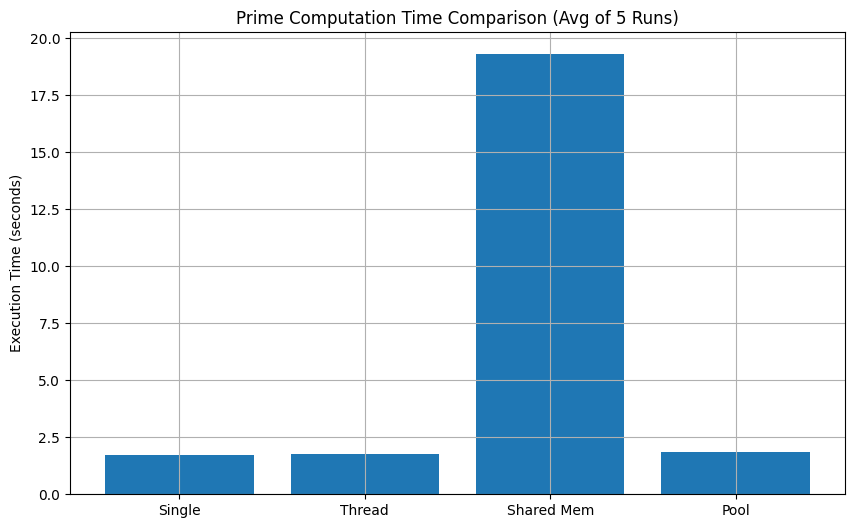

In [ ]:
import time
import gc
import statistics
import matplotlib.pyplot as plt

# === Benchmarking Helper ===
def average_runs(name, func, trials=5):
    print(f"\n=== Running: {name} ===")
    durations = []
    for i in range(trials):
        print(f"Trial {i+1}/{trials}...")
        result = func()
        durations.append(result)
        gc.collect()
        time.sleep(1.5)
    avg = statistics.mean(durations)
    std = statistics.stdev(durations)
    print(f"{name} Avg: {avg:.5f}s | Std Dev: {std:.5f}s")
    return avg

# === Optional Warm-up ===
print("Warming up...")
check_prime_in_range()
simple_multithread()
parallel_shared_memory()
parallel_pool_memory()
gc.collect()
time.sleep(2)

# === Run Benchmarks ===
times = []
labels = ['Single', 'Thread', 'Shared Mem', 'Pool']

n_time = average_runs("Single Thread", check_prime_in_range)
t_time = average_runs("Multithreading", simple_multithread)
m_time = average_runs("Parallel Shared Memory", parallel_shared_memory)
mp_time = average_runs("Parallel Pooled Memory", parallel_pool_memory)

times = [n_time, t_time, m_time, mp_time]

# === Display Comparison ===
print("\n=== FINAL COMPARISON ===")
for label, t in zip(labels, times):
    print(f"{label:<15}: {t:.5f} seconds")

print(f"\nSpeedup (Thread)         : {n_time / t_time:.2f}x")
print(f"Speedup (Shared Memory)  : {n_time / m_time:.2f}x")
print(f"Speedup (Pool)           : {n_time / mp_time:.2f}x")

# === Plot Comparison ===
plt.figure(figsize=(10, 6))
plt.bar(labels, times)
plt.ylabel('Execution Time (seconds)')
plt.title('Prime Computation Time Comparison (Avg of 5 Runs)')
plt.grid(True)
plt.show()
